# Larry, Gloria, and Erika Project 2

---
## Step 0: Setup

In [1]:
# Surprise's CF building blocks:
#   KNNBasic        — neighborhood CF (UBCF or IBCF, toggled via sim_options)
#   BaselineOnly    — global/user/item-mean baseline, useful for comparison
#   Dataset/Reader  — wrap a pandas DataFrame as a Surprise dataset
#   accuracy        — RMSE, MAE, etc. on prediction lists
#   RandomizedSearchCV / GridSearchCV — Surprise's built-in CV hyperparameter search
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from surprise import KNNBasic, BaselineOnly, Dataset, Reader, accuracy
from surprise.model_selection import (
    train_test_split, KFold, RandomizedSearchCV, GridSearchCV,
)

---
## Step 1: Load data

In [2]:
# Load the book catalog and ratings.
books = pd.read_csv("Books.csv")
ratings = pd.read_csv("Ratings.csv")

# Keep only the columns we need and drop malformed rows.
books = books.dropna(subset=["book_id", "title"])
ratings = ratings.dropna(subset=["user_id", "book_id", "rating"])

# Convert IDs to integers and ratings to floats.
books["book_id"] = books["book_id"].astype(int)
ratings["book_id"] = ratings["book_id"].astype(int)
ratings["user_id"] = ratings["user_id"].astype(int)
ratings["rating"] = ratings["rating"].astype(float)

# Helpful display lookup.
title_of = dict(zip(books["book_id"], books["title"]))
print(f"Books: {books.shape}  |  Ratings: {ratings.shape}, Users: {ratings['user_id'].nunique()}")

# Display with author.
label_of = {
    row.book_id: f"{row.title} — {row.authors}"
    for row in books[["book_id", "title", "authors"]].itertuples(index=False)
}

Books: (9964, 16)  |  Ratings: (164728, 3), Users: 1192


In [3]:
# Wrap the long-format ratings into a Surprise dataset.
# Goodreads ratings are on a 1.0–5.0 scale, so we specify that here to avoid surprise.
reader = Reader(rating_scale=(1.0, 5.0))
data = Dataset.load_from_df(
    ratings[["user_id", "book_id", "rating"]],
    reader
)

---
## Exploratory Data Analysis

<small>This is a richer companion to the condensed EDA in 01_build_book_recommender.ipynb (Step 2). It loads the data through the package's data_loader — the same [user_id, book_id, rating] contract used everywhere else in the project — and then explores user behavior, book behavior, popularity concentration, and metadata quality in more depth. These are the angles most useful for justifying the modeling choices made in notebook 01 (popularity baseline, UBCF/IBCF, SVD).<small>

#### Data Quality

<small>Sanity checks after the loader's cleanup — duplicates, orphan ratings, and missing keys. A clean table here is what lets us trust every downstream metric.<small>

In [4]:
quality_checks = pd.DataFrame({
    "check": [
        "Duplicate book IDs",
        "Duplicate user-book ratings",
        "Ratings with no matching book",
        "Missing book titles",
        "Missing user IDs",
        "Missing book IDs in ratings",
        "Missing ratings"
    ],
    "count": [
        books["book_id"].duplicated().sum(),
        ratings.duplicated(["user_id", "book_id"]).sum(),
        (~ratings["book_id"].isin(books["book_id"])).sum(),
        books["title"].isna().sum(),
        ratings["user_id"].isna().sum(),
        ratings["book_id"].isna().sum(),
        ratings["rating"].isna().sum()
    ]
})
display(quality_checks)

,check,count
0,Duplicate book IDs,0
1,Duplicate user-book ratings,0
2,Ratings with no matching book,0
3,Missing book titles,0
4,Missing user IDs,0
5,Missing book IDs in ratings,0
6,Missing ratings,0


#### Rating Distribution

<small>Recommendation data is usually skewed toward high ratings (people rate books they already expected to like — missing-not-at-random). A heavy 4–5★ skew is the single biggest reason a popularity/mean baseline is hard to beat on RMSE. <small>

,rating,count,percent
0,1.0,3716,2.26
1,2.0,11382,6.91
2,3.0,42530,25.82
3,4.0,56933,34.56
4,5.0,50167,30.45


Mean rating: 3.84
Median rating: 4.0


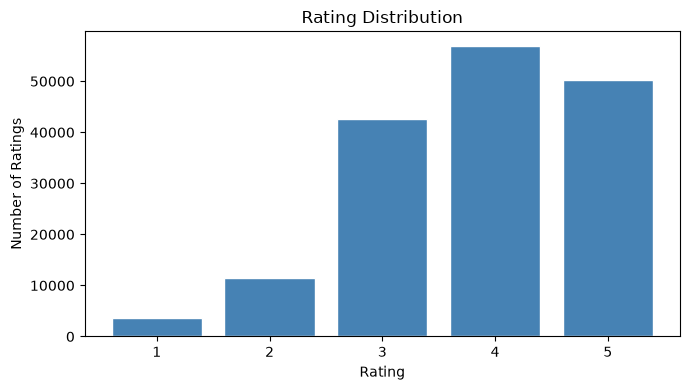

In [5]:
rating_dist = (
    ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)
rating_dist["percent"] = (rating_dist["count"] / len(ratings) * 100).round(2)
display(rating_dist)

print("Mean rating:", round(ratings["rating"].mean(), 3))
print("Median rating:", ratings["rating"].median())

plt.figure(figsize=(7, 4))
plt.bar(rating_dist["rating"], rating_dist["count"], color="steelblue", edgecolor="white")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rating_dist["rating"])
plt.tight_layout()
plt.show()

#### User Behavior

<small>How much history each user has, and how generous or harsh they are. Users with very short histories or a single rating value are exactly the cold-start / low-signal cases where collaborative filtering struggles and a popularity fallback matters.<small>

,user_id,n_ratings,avg_rating,rating_std,min_rating,max_rating,unique_ratings
count,1192.000000,1192.000000,1192.000000,1192.000000,1192.000000,1192.000000,1192.000000
mean,25188.340604,138.194631,3.838762,0.828961,1.552852,4.989933,4.406040
std,14762.053998,30.913395,0.526084,0.234350,0.827056,0.099871,0.839554
min,35.000000,100.000000,1.060870,0.000000,1.000000,4.000000,1.000000
25%,12370.000000,112.000000,3.481647,0.706878,1.000000,5.000000,4.000000
50%,24027.000000,129.000000,3.799371,0.831937,1.000000,5.000000,5.000000
75%,37398.000000,166.000000,4.178627,0.974515,2.000000,5.000000,5.000000
max,53366.000000,200.000000,5.000000,1.796521,5.000000,5.000000,5.000000


Users who only use one rating value: 19
Users who only gave 5-star ratings: 19


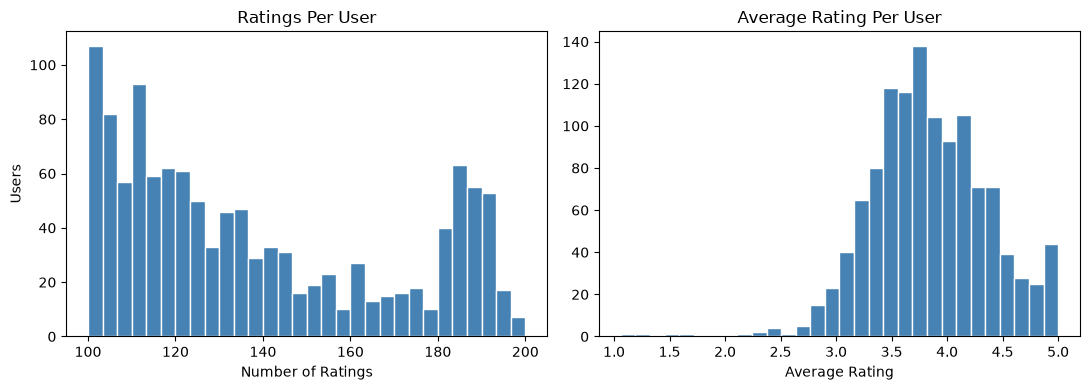

In [6]:
user_summary = (
    ratings.groupby("user_id")
    .agg(
        n_ratings=("rating", "count"),
        avg_rating=("rating", "mean"),
        rating_std=("rating", "std"),
        min_rating=("rating", "min"),
        max_rating=("rating", "max"),
        unique_ratings=("rating", "nunique")
    )
    .reset_index()
)
display(user_summary.describe())

single_value_users = user_summary[user_summary["unique_ratings"] == 1]
all_five_users = single_value_users[single_value_users["avg_rating"] == 5]
print("Users who only use one rating value:", len(single_value_users))
print("Users who only gave 5-star ratings:", len(all_five_users))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(user_summary["n_ratings"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Ratings Per User")
axes[0].set_xlabel("Number of Ratings")
axes[0].set_ylabel("Users")
axes[1].hist(user_summary["avg_rating"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_title("Average Rating Per User")
axes[1].set_xlabel("Average Rating")
plt.tight_layout()
plt.show()

#### Book Behavior

<small>How much evidence each book carries, and how its observed average relates to its rating count. The scatter shows whether high averages are backed by enough ratings to trust — the motivation for the support threshold below. <small> 

,book_id,observed_ratings,observed_avg_rating,observed_rating_std,original_publication_year,average_rating,ratings_count,text_reviews_count
count,9229.000000,9229.000000,9229.000000,8461.000000,9213.000000,9229.000000,9.229000e+03,9229.000000
mean,4786.925127,17.848954,3.832442,0.898349,1981.165636,4.001527,6.340399e+04,3079.024055
std,2848.782048,23.278835,0.543924,0.335378,156.364451,0.252382,1.741466e+05,6343.799094
min,1.000000,1.000000,1.000000,0.000000,-1750.000000,2.470000,6.823000e+03,3.000000
25%,2321.000000,4.000000,3.535714,0.726483,1990.000000,3.850000,1.638400e+04,734.000000
50%,4687.000000,8.000000,3.880000,0.899879,2004.000000,4.020000,2.530800e+04,1480.000000
75%,7197.000000,21.000000,4.142857,1.066117,2011.000000,4.180000,4.935400e+04,2942.000000
max,10000.000000,100.000000,5.000000,2.828427,2017.000000,4.820000,4.942365e+06,155254.000000


Most-rated books in this sample:


,book_id,title,authors,observed_ratings,observed_avg_rating
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,100,4.24
386,387,The Crucible,"Arthur Miller, Christopher Bigsby",100,3.51
130,131,The Grapes of Wrath,John Steinbeck,100,3.89
132,133,"Anne of Green Gables (Anne of Green Gables, #1)",L.M. Montgomery,100,3.96
729,730,The Pearl,John Steinbeck,100,3.54
135,136,Divine Secrets of the Ya-Ya Sisterhood,Rebecca Wells,100,3.58
137,138,The Scarlet Letter,"Nathaniel Hawthorne, Thomas E. Connolly, Nina ...",100,3.43
732,733,Snow Falling on Cedars,David Guterson,100,3.77
139,140,The Girl Who Kicked the Hornet's Nest (Millenn...,"Stieg Larsson, Reg Keeland",100,4.16
141,142,The Pillars of the Earth (The Kingsbridge Seri...,Ken Follett,100,4.24


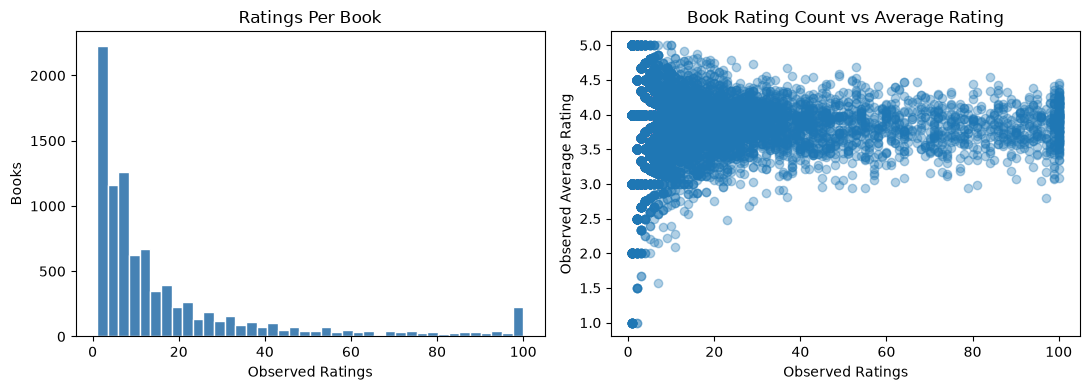

In [7]:
book_summary = (
    ratings.groupby("book_id")
    .agg(
        observed_ratings=("rating", "count"),
        observed_avg_rating=("rating", "mean"),
        observed_rating_std=("rating", "std")
    )
    .reset_index()
    .merge(
        books[[
            "book_id", "title", "authors", "original_publication_year",
            "language_code", "average_rating", "ratings_count", "text_reviews_count"
        ]],
        on="book_id", how="left"
    )
)
display(book_summary.describe())

print("Most-rated books in this sample:")
display(
    book_summary.sort_values("observed_ratings", ascending=False).head(15)
    [["book_id", "title", "authors", "observed_ratings", "observed_avg_rating"]]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(book_summary["observed_ratings"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Ratings Per Book")
axes[0].set_xlabel("Observed Ratings")
axes[0].set_ylabel("Books")
axes[1].scatter(book_summary["observed_ratings"], book_summary["observed_avg_rating"], alpha=0.35)
axes[1].set_title("Book Rating Count vs Average Rating")
axes[1].set_xlabel("Observed Ratings")
axes[1].set_ylabel("Observed Average Rating")
plt.tight_layout()
plt.show()

In [8]:
# Top and bottom books, using a support threshold so single-rating books
# do not dominate the leaderboard.
MIN_RATINGS = 20
supported_books = book_summary[book_summary["observed_ratings"] >= MIN_RATINGS]

print(f"Highest-rated books with at least {MIN_RATINGS} ratings:")
display(
    supported_books.sort_values("observed_avg_rating", ascending=False).head(10)
    [["title", "authors", "observed_ratings", "observed_avg_rating", "average_rating"]]
)
print(f"Lowest-rated books with at least {MIN_RATINGS} ratings:")
display(
    supported_books.sort_values("observed_avg_rating", ascending=True).head(10)
    [["title", "authors", "observed_ratings", "observed_avg_rating", "average_rating"]]
)

Highest-rated books with at least 20 ratings:


,title,authors,observed_ratings,observed_avg_rating,average_rating
4583,The Complete Novels,Jane Austen,24,4.791667,4.55
1305,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,20,4.750000,4.72
2169,Tikki Tikki Tembo,"Arlene Mosel, Blair Lent",29,4.724138,4.21
2164,The Cat in the Hat and Other Dr. Seuss Favorites,"Dr. Seuss, Various",25,4.680000,4.41
861,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,53,4.679245,4.77
3590,The Complete Calvin and Hobbes,Bill Watterson,37,4.675676,4.82
3361,Worlds' End (The Sandman #8),"Neil Gaiman, Mike Allred, Gary Amaro, Mark Buc...",20,4.650000,4.48
2339,Season of Mists (The Sandman #4),"Neil Gaiman, Matt Wagner, George Pratt, Dick G...",22,4.636364,4.54
1376,"The Complete Maus (Maus, #1-2)",Art Spiegelman,21,4.619048,4.53
2332,Columbine,Dave Cullen,21,4.619048,4.26


Lowest-rated books with at least 20 ratings:


,title,authors,observed_ratings,observed_avg_rating,average_rating
1110,Mr. Maybe,Jane Green,23,2.478261,3.41
731,The Short Second Life of Bree Tanner: An Eclip...,Stephenie Meyer,28,2.678571,3.51
1724,Armada,Ernest Cline,20,2.750000,3.49
1476,Her Fearful Symmetry,Audrey Niffenegger,29,2.758621,3.23
33,"Fifty Shades of Grey (Fifty Shades, #1)",E.L. James,97,2.804124,3.67
2124,The Jane Austen Book Club,Karen Joy Fowler,37,2.810811,3.07
776,Jemima J,Jane Green,32,2.875000,3.62
1566,Naked Lunch,"William S. Burroughs, James Grauerholz, Barry ...",35,2.914286,3.46
1542,The Mermaid Chair,Sue Monk Kidd,36,2.916667,3.10
95,"Fifty Shades Freed (Fifty Shades, #3)",E.L. James,79,2.936709,3.88


#### Popularity concentration

<small>Does a small set of books soak up most of the ratings? A steep long tail means a naive recommender will keep surfacing the same blockbusters — the argument for measuring coverage (notebook 01, evaluate.coverage) alongside accuracy.<small>

,top_n_books,percent_of_all_ratings
0,10,0.61
1,50,3.04
2,100,6.07
3,500,28.10
4,1000,46.07


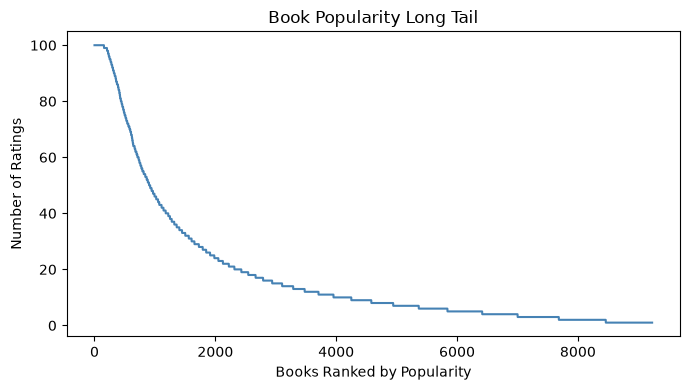

In [9]:
book_popularity = ratings["book_id"].value_counts()

popularity_summary = pd.DataFrame({"top_n_books": [10, 50, 100, 500, 1000]})
popularity_summary["percent_of_all_ratings"] = popularity_summary["top_n_books"].apply(
    lambda n: round(100 * book_popularity.head(n).sum() / len(ratings), 2)
)
display(popularity_summary)

plt.figure(figsize=(7, 4))
book_popularity.reset_index(drop=True).plot(color="steelblue")
plt.title("Book Popularity Long Tail")
plt.xlabel("Books Ranked by Popularity")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

#### Metadata & missingness

<small>Coverage of the side information a content-based or hybrid model would rely on.

Note: data_loader.load fills a few contract columns (missing authors → "Unknown", missing original_publication_year → 0), so those missing-counts read as 0 here by design — they reflect the post-clean state the models actually see. language_code and isbn are left untouched, so their gaps are real.<small>

In [10]:
metadata_summary = pd.DataFrame({
    "column": ["language_code", "isbn", "original_publication_year", "authors"],
    "missing_count": [
        books["language_code"].isna().sum(),
        books["isbn"].isna().sum(),
        books["original_publication_year"].isna().sum(),
        books["authors"].isna().sum()
    ]
})
metadata_summary["missing_percent"] = (
    metadata_summary["missing_count"] / len(books) * 100
).round(2)
display(metadata_summary)

print("Most common languages:")
display(books["language_code"].fillna("Missing").value_counts().head(15).to_frame("book_count"))

print("Most common authors:")
display(
    books["authors"].dropna().str.split(",").explode().str.strip()
    .value_counts().head(20).to_frame("book_count")
)

print("Potential publication year anomalies:")
display(
    books[(books["original_publication_year"] < 0) | (books["original_publication_year"] > 2026)]
    [["book_id", "title", "authors", "original_publication_year"]].head(20)
)

,column,missing_count,missing_percent
0,language_code,1076,10.80
1,isbn,698,7.01
2,original_publication_year,21,0.21
3,authors,0,0.00


Most common languages:


,book_count
language_code,
eng,6322
en-US,2062
Missing,1076
en-GB,256
ara,64
en-CA,58
fre,25
ind,21
spa,20


Most common authors:


,book_count
authors,
James Patterson,98
Stephen King,96
Dean Koontz,64
Nora Roberts,64
Terry Pratchett,50
Agatha Christie,43
Neil Gaiman,41
J.D. Robb,41
Meg Cabot,38


Potential publication year anomalies:


,book_id,title,authors,original_publication_year
78,79,The Odyssey,"Homer, Robert Fagles, E.V. Rieu, FrÃ©dÃ©ric Mu...",-720.0
340,341,The Iliad,"Homer, Robert Fagles, FrÃ©dÃ©ric Mugler, Berna...",-750.0
402,403,The Art of War,"Sun Tzu, Thomas Cleary",-500.0
771,772,The Republic,"Plato, Desmond Lee",-380.0
823,824,"Oedipus Rex (The Theban Plays, #1)","Sophocles, J.E. Thomas",-430.0
1098,1099,Tao Te Ching,"Lao Tzu, Gia-Fu Feng, Jane English, Chungliang...",-300.0
1119,1120,Aesop's Fables,"Aesop, Laura Harris, Laura Gibbs",-560.0
1279,1280,The Aeneid,"Virgil, Robert Fitzgerald",-17.0
1519,1521,"Antigone (The Theban Plays, #3)","Sophocles, J.E. Thomas",-441.0
2050,2052,The Oedipus Cycle: Oedipus Rex/Oedipus at Colo...,"Sophocles, Dudley Fitts, Elena Bono, Robert Fi...",-401.0


### EDA Takeaways
- Skewed ratings (heavy 4–5★). Rating data is missing-not-at-random, so RMSE rewards predicting "high" — a mean/popularity baseline is a genuinely strong competitor and the right thing to benchmark against (notebook 01, Step 3).
- Sparse, uneven users. Many users have short histories or near-constant ratings → cold-start cases where CF neighborhoods are thin; keep a popularity fallback.
- Long-tail popularity. How steep the tail is varies — read it off the concentration table above. The steeper it is, the more you should report coverage next to Precision/Recall/NDCG rather than accuracy alone.
- Partial metadata. language_code/isbn gaps and author concentration constrain a content/hybrid model — the content path falls back to title + authors for a reason.

---
## Step 2: Train/Test Split (held-out evaluation)

<small>Carve out a 90/10 hold-out split **up front**, before any modeling or tuning. The 10% test set is touched only once, at the very end, to score the final models. All hyperparameter tuning (below) uses cross-validation *within* the 90% training set, so the test set stays a true measure of generalization. `random_state` keeps the split reproducible.</small>

In [11]:
# Build a 90/10 train/test split FIRST so the held-out 10% is never seen during tuning.
# All cross-validation for hyperparameter search happens within `trainset` only.
# `random_state` makes the split reproducible across runs.
trainset, testset = train_test_split(data, test_size=0.1, random_state=6604)
print(f"Trainset: {trainset.n_users} users, {trainset.n_items} books, {trainset.n_ratings} ratings")

Trainset: 1192 users, 9140 books, 148255 ratings


---
## Step 3: "Baseline" Collaborative Filtering Models

<small> UBCF and IBCF models with minimally tuned parameters. <small>

### Functions

#### Precision and Recall @ k

In [12]:
# Top-N precision and recall for ranking quality:
#   - a book is "relevant" if its true rating is >= threshold (4.0 here),
#   - for each user we rank predictions by estimated rating,
#   - precision = fraction of the user's top-N that were actually relevant,
#   - recall    = fraction of the user's relevant items captured in the top-N.
# `top_n` is the list length - distinct from the model's k (the neighborhood size).
# Returns the mean across all users in the predictions list.
def precision_recall_at_k(predictions, top_n=10, threshold=4.0):
    user_data = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_data[uid].append((est, true_r))
    precisions, recalls = [], []
    for items in user_data.values():
        items.sort(key=lambda x: x[0], reverse=True)
        n_relevant = sum(1 for _, t in items if t >= threshold)
        n_hits = sum(1 for _, t in items[:top_n] if t >= threshold)
        precisions.append(n_hits / top_n)
        if n_relevant > 0:
            recalls.append(n_hits / n_relevant)
    return np.mean(precisions), np.mean(recalls)

#### Top-N Recommendations

<small>CF tends to surface rarely-rated books. Restricting candidates to books with at least `MIN_RATINGS` ratings is a simple, effective fix. The helper below is reused for both models.</small>

In [13]:
# Recommend a user's top-N unseen books, ranked by predicted rating.
# Popularity filter (>= MIN_RATINGS): drop books with very few ratings, which CF
# could otherwise rank highly on almost no evidence (e.g. a single 5/5 rating).
# MIN_RATINGS=20 is just a suggested value - the right cutoff depends on the
# dataset size, catalog, and use case.
MIN_RATINGS = 20
counts = ratings["book_id"].value_counts()
popular_books = set(counts[counts >= MIN_RATINGS].index)
def top_n_for_user(model, user_id, top_n=5):
    seen = set(ratings.loc[ratings["user_id"] == user_id, "book_id"])
    scored = []
    for book_id in books["book_id"]:
        if book_id in seen or book_id not in popular_books:
            continue
        est = model.predict(user_id, book_id).est
        scored.append((title_of.get(book_id, f"Book {book_id}"), est))
    return sorted(scored, key=lambda x: -x[1])[:top_n]

### User-Based CF

<small>Similarity is computed between **users** (rows): each prediction averages the `k` most similar users who rated the target book - "people like you also enjoyed...". We use **Pearson**, which centers each user on their own mean - important because users rate on different scales (some skew high, some low).</small>

In [14]:
# User-based: the k=10 most similar users (Pearson similarity) vote on each prediction.
ubcf = KNNBasic(k=10, sim_options={"name": "pearson", "user_based": True}, verbose=False)
ubcf.fit(trainset)

# Print precision and recall on the held-out testset
ubcf_predictions = ubcf.test(testset)
ubcf_precision, ubcf_recall = precision_recall_at_k(ubcf_predictions, top_n=10, threshold=4.0)
print(f"UBCF precision@10: {ubcf_precision:.4f}  |  recall@10: {ubcf_recall:.4f}")

UBCF precision@10: 0.6565  |  recall@10: 0.7899


In [15]:
top_n_for_user(ubcf, user_id=1, top_n=5)   # top-5 UBCF recommendations for user 1

[('The Hunger Games (The Hunger Games, #1)', 3.8406731644801186),
 ("Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",
  3.8406731644801186),
 ('Twilight (Twilight, #1)', 3.8406731644801186),
 ('To Kill a Mockingbird', 3.8406731644801186),
 ('The Great Gatsby', 3.8406731644801186)]

### Item-Based CF

<small>Now similarity is between **books** (columns), from how the same users rated them - "because you liked X, you might like Y...". So *both* knobs change from UBCF - the axis (users→books) and the similarity - which mirrors how the metric is usually chosen per method in practice. Compare this top-5 to the UBCF list: same user, different lens, different books.</small>

In [16]:
# Item-based: similarity between books, using cosine (the common item-based choice).
ibcf = KNNBasic(k=10, sim_options={"name": "cosine", "user_based": False}, verbose=False)
ibcf.fit(trainset)

# Print precision and recall on the held-out testset
ibcf_predictions = ibcf.test(testset)
ibcf_precision, ibcf_recall = precision_recall_at_k(ibcf_predictions, top_n=10, threshold=4.0)
print(f"IBCF precision@10: {ibcf_precision:.4f}  |  recall@10: {ibcf_recall:.4f}")

IBCF precision@10: 0.6245  |  recall@10: 0.7526


#### Top-N Recommendations

In [17]:
# Top-5 IBCF recommendations for user 1 (same helper, different model).
top_n_for_user(ibcf, user_id=1, top_n=5)

[('The Hunger Games (The Hunger Games, #1)', 3.8406731644801186),
 ("Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",
  3.8406731644801186),
 ('Twilight (Twilight, #1)', 3.8406731644801186),
 ('To Kill a Mockingbird', 3.8406731644801186),
 ('The Great Gatsby', 3.8406731644801186)]

---
## Step 4: Tuning - Use hyperparameter tuning to narrow down to best UBCF and IBCF model configurations for evaluation on test set in Step 5.


<small>CF is trained without labeled "correct answers," yet we evaluate it like supervised learning: hold out known ratings, predict them, and compare. We report a **rating-accuracy** metric (RMSE) and **ranking** metrics (Precision@K, Recall@K)

### f1_score, precision_at_k

In [18]:
# --- Make Surprise's search optimize Precision@10 ---------------------------------
# Surprise's CV search only ranks built-in accuracy measures. We register an
# Precision@10 scorer in the `accuracy` module and bind it to the `fcp` name, which is
# the framework's single higher-is-better ranking slot (argmax) — a match for Precision@10.
# cv_results will store it under 'fcp';
# we relabel it to 'Precision@10' in all user-facing output.
TOP_N = 10            # list length for precision/recall@k
THRESHOLD = 4.0       # rating >= threshold counts as "relevant"

def f1_score(precision, recall):
    # Harmonic mean of precision and recall; 0 when both are 0.
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def precision_at_k(predictions, verbose=0):
    p, _ = precision_recall_at_k(predictions, top_n=TOP_N, threshold=THRESHOLD)
    return p

accuracy.fcp = precision_at_k   # route Precision@10 through the higher-is-better ranking slot
MEASURES = ["fcp", "rmse"]   # 'fcp' == our Precision@10 (ranked); 'rmse' reported alongside

### Tune `k` per model with Surprise's `RandomizedSearchCV` → `GridSearchCV`

In [19]:
# Two-stage tuning per model, using Surprise's built-in search frameworks.
#   Stage 1: RandomizedSearchCV samples N_RANDOM distinct k's from [K_MIN, K_MAX].
#   Stage 2: GridSearchCV scans every integer k in a +/- GRID_RADIUS window around
#            the random winner. Both rank by Precision@10 (the 'fcp' slot) via CV.
# ONLY k is searched — the similarity settings are fixed per model, not tuned.
CV_FOLDS = 3               # folds for cross-validation during tuning
K_MIN, K_MAX = 5, 100      # overall search range for k
N_RANDOM     = 30          # random-search samples per model
GRID_RADIUS  = 5           # grid-search half-width around the random winner
RANDOM_SEED  = 6604

# Surprise's search frameworks split internally and require a Dataset, not a Trainset.
# Rebuilding a Dataset from ONLY the 90% training ratings.
# trainset stores ratings as inner ids, so map them back to raw (user_id, book_id, rating) first.
train_df = pd.DataFrame(
    [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r)
     for (u, i, r) in trainset.all_ratings()],
    columns=["user_id", "book_id", "rating"],
)
train_data = Dataset.load_from_df(train_df[["user_id", "book_id", "rating"]], reader)

# Fixed (NOT tuned) similarity settings, one config per model. See rationale in markdown cells for Step 3.
sim_configs = {
    "UBCF pearson": {"name": "pearson", "user_based": True},
    "UBCF cosine":  {"name": "cosine",  "user_based": True},
    "UBCF msd":     {"name": "msd",     "user_based": True},
    "UBCF pearson baseline": {"name": "pearson_baseline", "user_based": True},
    "IBCF cosine":  {"name": "cosine",  "user_based": False},
    "IBCF pearson": {"name": "pearson", "user_based": False},
    "IBCF msd":     {"name": "msd",     "user_based": False},
    "IBCF pearson baseline": {"name": "pearson_baseline", "user_based": False},
}

def cv_results_df(search, stage):
    # Tidy a Surprise search's cv_results into rows, relabeling fcp -> Precision@10.
    res = search.cv_results
    return pd.DataFrame({
        "stage": stage,
        "k": res["param_k"],
        "Precision@10": res["mean_test_fcp"],
        "RMSE": res["mean_test_rmse"],
    })

search_log, best_k = {}, {}
for name, sim in sim_configs.items():
    cv = KFold(n_splits=CV_FOLDS, random_state=RANDOM_SEED, shuffle=True)
    # Bake the fixed similarity config into the estimator so the search varies only k.
    # Surprise calls algo_class(**params); this wrapper supplies the fixed args.
    def make_knn(sim=sim):
        return lambda **params: KNNBasic(sim_options=sim, verbose=False, **params)
    knn = make_knn()

    # --- Stage 1: random search (k only) ---
    rs = RandomizedSearchCV(
        knn,
        param_distributions={"k": list(range(K_MIN, K_MAX + 1))},
        n_iter=N_RANDOM, measures=MEASURES, cv=cv,
        random_state=RANDOM_SEED, refit=False,
    )
    rs.fit(train_data)
    rand_k = rs.best_params["fcp"]["k"]   # 'fcp' == Precision@10

    # --- Stage 2: grid search around the random winner (k only) ---
    lo = max(K_MIN, rand_k - GRID_RADIUS)
    hi = min(K_MAX, rand_k + GRID_RADIUS)
    gs = GridSearchCV(
        knn,
        param_grid={"k": list(range(lo, hi + 1))},
        measures=MEASURES, cv=cv, refit=False,
    )
    gs.fit(train_data)

    # Best k over BOTH stages by Precision@10.
    combined = pd.concat([cv_results_df(rs, "random"), cv_results_df(gs, "grid")],
                         ignore_index=True)
    combined["Similarity Config"] = name
    winner = combined.loc[combined["Precision@10"].idxmax()]
    best_k[name] = int(winner["k"])
    search_log[name] = combined

    print(f"{name}: random winner k={rand_k}  -> grid scanned {lo}..{hi}  "
          f"-> best k={best_k[name]}  "
          f"Precision@10={winner['Precision@10']:.4f}  RMSE={winner['RMSE']:.4f}")

UBCF pearson: random winner k=19  -> grid scanned 14..24  -> best k=22  Precision@10=0.7329  RMSE=1.0647
UBCF cosine: random winner k=34  -> grid scanned 29..39  -> best k=35  Precision@10=0.7318  RMSE=1.0174
UBCF msd: random winner k=13  -> grid scanned 8..18  -> best k=13  Precision@10=0.7515  RMSE=0.9570
UBCF pearson baseline: random winner k=21  -> grid scanned 16..26  -> best k=21  Precision@10=0.7496  RMSE=1.0193
IBCF cosine: random winner k=74  -> grid scanned 69..79  -> best k=74  Precision@10=0.7076  RMSE=0.8680
IBCF pearson: random winner k=39  -> grid scanned 34..44  -> best k=38  Precision@10=0.7155  RMSE=0.9037
IBCF msd: random winner k=52  -> grid scanned 47..57  -> best k=54  Precision@10=0.7170  RMSE=0.8659
IBCF pearson baseline: random winner k=8  -> grid scanned 5..13  -> best k=6  Precision@10=0.7459  RMSE=0.8930


In [20]:
# Examine the search log for all results, sorted by Precision@10, to see how the random and grid stages contributed to the final winner
search_log_df = pd.concat(search_log.values(), ignore_index=True)
search_log_df = search_log_df.sort_values("Precision@10", ascending=False)
config_split = search_log_df["Similarity Config"].str.split(" ", n=1)
search_log_df["User/Item"] = config_split.str[0]
search_log_df["Similarity Config"] = config_split.str[1].fillna(
    search_log_df["Similarity Config"].str[5:]
)
display(search_log_df.head(20))

,stage,k,Precision@10,RMSE,Similarity Config,User/Item
102,random,13,0.751538,0.956988,msd,UBCF
117,grid,13,0.751538,0.956988,msd,UBCF
101,random,18,0.750923,0.959362,msd,UBCF
122,grid,18,0.750923,0.959362,msd,UBCF
118,grid,14,0.750503,0.957396,msd,UBCF
111,random,16,0.750475,0.958317,msd,UBCF
120,grid,16,0.750475,0.958317,msd,UBCF
116,grid,12,0.750336,0.956705,msd,UBCF
119,grid,15,0.750084,0.957800,msd,UBCF
121,grid,17,0.749776,0.958808,msd,UBCF


In [21]:
ubcf_models = [name for name in search_log if name.startswith("UBCF")]
best_ubcf = max(
    ((name, search_log[name]["Precision@10"].max()) for name in ubcf_models),
    key=lambda x: x[1]
)
name, best_prec = best_ubcf
print(f"Best UBCF model: {name}")
print(f"Similarity config: {name.split(' ', 1)[1]}")
print(f"k: {best_k[name]}")
print(f"Best Precision@10: {best_prec:.6f}")

Best UBCF model: UBCF msd
Similarity config: msd
k: 13
Best Precision@10: 0.751538


In [22]:
ibcf_models = [name for name in search_log if name.startswith("IBCF")]
best_ibcf = max(
    ((name, search_log[name]["Precision@10"].max()) for name in ibcf_models),
    key=lambda x: x[1]
)
name, best_prec = best_ibcf
print(f"Best IBCF model: {name}")
print(f"Similarity config: {name.split(' ', 1)[1]}")
print(f"k: {best_k[name]}")
print(f"Best Precision@10: {best_prec:.6f}")

Best IBCF model: IBCF pearson baseline
Similarity config: pearson baseline
k: 6
Best Precision@10: 0.745917


---
## Step 5: Final Evaluation on the Held-Out Test Set

<small>Now — and only now — we touch the 10% test set. We fit each model on the full 90% training split using the **tuned `k`** (the baseline has no `k` to tune), then score them on the held-out ratings. We report RMSE (rating accuracy) alongside Precision@10, Recall@10, and their F1 (ranking quality). The baseline is the bar CF must clear; note that a model's RMSE and its ranking quality don't always agree.</small>

In [23]:
# Fit each model on the FULL 90% training split, then score once on the held-out test set.
# The CF model uses the k tuned in Step 4 (RandomizedSearchCV -> GridSearchCV); BaselineOnly
# has no k to tune and is included as the
# comparison bar. This is the only place the test set is used.
# models = {
#     "Baseline": BaselineOnly(verbose=False),
#     "UBCF msd": KNNBasic(k=13,
#                   sim_options={"name": "msd", "user_based": True}, verbose=False),
#     "IBCF pearson baseline": KNNBasic(k=6,
#                   sim_options={"name": "pearson_baseline", "user_based": False}, verbose=False)
# }

top_models = {}
top20 = search_log_df.head(20)
for _, row in top20.iterrows():
    config_name = f"{row['User/Item']} {row['Similarity Config']} k={int(row['k'])}"
    sim_key = f"{row['User/Item']} {row['Similarity Config']}"
    top_models[config_name] = KNNBasic(
        k=int(row["k"]),
        sim_options=sim_configs[sim_key],
        verbose=False
    )


# Add the BaselineOnly model as a non-CF comparison bar.
top_models["Baseline"] = BaselineOnly(verbose=False)

top_models

results = []
for name, m in top_models.items():
    m.fit(trainset)
    preds = m.test(testset)
    p, r = precision_recall_at_k(preds, top_n=TOP_N, threshold=THRESHOLD)
    results.append({
        "Model": name,
        "RMSE": accuracy.rmse(preds, verbose=False),
        f"Precision@{TOP_N}": p,
        f"Recall@{TOP_N}": r,
        "F1": f1_score(p, r),
    })

pd.DataFrame(results).round(4).sort_values("Precision@10", ascending=False)

,Model,RMSE,Precision@10,Recall@10,F1
8,UBCF pearson baseline k=25,0.9803,0.6667,0.8016,0.7280
10,UBCF pearson baseline k=20,0.9811,0.6664,0.8011,0.7276
12,UBCF pearson baseline k=26,0.9803,0.6661,0.8010,0.7273
7,UBCF pearson baseline k=21,0.9809,0.6660,0.8006,0.7272
9,UBCF pearson baseline k=29,0.9803,0.6659,0.8008,0.7271
13,UBCF pearson baseline k=18,0.9818,0.6654,0.8002,0.7266
5,UBCF msd k=15,0.9177,0.6653,0.8003,0.7265
1,UBCF msd k=18,0.9201,0.6652,0.8005,0.7266
3,UBCF msd k=16,0.9185,0.6650,0.7999,0.7263
6,UBCF msd k=17,0.9193,0.6648,0.8000,0.7262


In [24]:
# Fit each model on the FULL 90% training split, then score once on the held-out test set.
# The CF model uses the k tuned in Step 4 (RandomizedSearchCV -> GridSearchCV); BaselineOnly
# has no k to tune and is included as the
# comparison bar. This is the only place the test set is used.
# models = {
#     "Baseline": BaselineOnly(verbose=False),
#     "UBCF msd": KNNBasic(k=13,
#                   sim_options={"name": "msd", "user_based": True}, verbose=False),
#     "IBCF pearson baseline": KNNBasic(k=6,
#                   sim_options={"name": "pearson_baseline", "user_based": False}, verbose=False)
# }

top_models = {}

for user_item in ["UBCF", "IBCF"]:
    top_configs = (
        search_log_df[search_log_df["User/Item"] == user_item]
        .sort_values("Precision@10", ascending=False)
        .drop_duplicates(["Similarity Config", "k"])
        .head(10)
    )
    for _, row in top_configs.iterrows():
        config_name = f"{user_item} {row['Similarity Config']} k={int(row['k'])}"
        sim_key = f"{user_item} {row['Similarity Config']}"
        top_models[config_name] = KNNBasic(
            k=int(row["k"]),
            sim_options=sim_configs[sim_key],
            verbose=False
        )

# Add the BaselineOnly model as a non-CF comparison bar.
top_models["Baseline"] = BaselineOnly(verbose=False)

top_models

results = []
for name, m in top_models.items():
    m.fit(trainset)
    preds = m.test(testset)
    p, r = precision_recall_at_k(preds, top_n=TOP_N, threshold=THRESHOLD)
    results.append({
        "Model": name,
        "RMSE": accuracy.rmse(preds, verbose=False),
        f"Precision@{TOP_N}": p,
        f"Recall@{TOP_N}": r,
        "F1": f1_score(p, r),
    })

pd.DataFrame(results).round(4).sort_values("Precision@10", ascending=False)

,Model,RMSE,Precision@10,Recall@10,F1
14,IBCF pearson baseline k=9,0.8277,0.6713,0.8071,0.7330
18,IBCF pearson baseline k=12,0.8254,0.6701,0.8050,0.7314
13,IBCF pearson baseline k=10,0.8262,0.6695,0.8048,0.7309
15,IBCF pearson baseline k=7,0.8312,0.6694,0.8051,0.7310
16,IBCF pearson baseline k=13,0.8246,0.6693,0.8040,0.7305
17,IBCF pearson baseline k=11,0.8255,0.6692,0.8045,0.7306
19,IBCF pearson baseline k=14,0.8243,0.6691,0.8035,0.7302
11,IBCF pearson baseline k=5,0.8397,0.6687,0.8038,0.7301
12,IBCF pearson baseline k=8,0.8290,0.6686,0.8042,0.7302
10,IBCF pearson baseline k=6,0.8347,0.6682,0.8035,0.7296


##### Evaluate Default Similarity Configs at Optimal k on Held-Out Test Set

In [27]:
# User-based: the k=19 most similar users (Pearson similarity) vote on each prediction.
ubcf = KNNBasic(k=19, sim_options={"name": "pearson", "user_based": True}, verbose=False)
ubcf.fit(trainset)

# Print precision and recall on the held-out testset
ubcf_predictions = ubcf.test(testset)
ubcf_precision, ubcf_recall = precision_recall_at_k(ubcf_predictions, top_n=10, threshold=4.0)
print(f"UBCF precision@10: {ubcf_precision:.4f}  |  recall@10: {ubcf_recall:.4f}, f1: {f1_score(ubcf_precision, ubcf_recall):.4f}, RMSE: {accuracy.rmse(ubcf_predictions, verbose=False):.4f}")

UBCF precision@10: 0.6592  |  recall@10: 0.7935, f1: 0.7202, RMSE: 1.0293


In [28]:
# Item-based: similarity between books, using cosine (the common item-based choice).
ibcf = KNNBasic(k=74, sim_options={"name": "cosine", "user_based": False}, verbose=False)
ibcf.fit(trainset)

# Print precision and recall on the held-out testset
ibcf_predictions = ibcf.test(testset)
ibcf_precision, ibcf_recall = precision_recall_at_k(ibcf_predictions, top_n=10, threshold=4.0)
print(f"IBCF precision@10: {ibcf_precision:.4f}  |  recall@10: {ibcf_recall:.4f}, f1: {f1_score(ibcf_precision, ibcf_recall):.4f}, RMSE: {accuracy.rmse(ibcf_predictions, verbose=False):.4f}")

IBCF precision@10: 0.6423  |  recall@10: 0.7739, f1: 0.7020, RMSE: 0.8560
